# Assignment 1 - Solution

In [1]:
# Import standard libraries
import os
import sys
import timeit # To compute runtimes
from typing import Optional

# Import third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import local modules
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)
from estimation.covariance import Covariance, is_pos_def, make_pos_def
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS
from helper_functions import simulate_correlated_gbm

## 1. Solver Horse Race

### 1.a)
(3 points)

Generate a synthetic dataset of dimension TxN, T=1000, N=50, and compute a vector of expected returns, q, and a covariance matrix, P, using classes ExpectedReturn and Covariance respectively.

In [2]:

# Set the dimensions
T = 1000       # Number of time steps
N = 50         # Number of assets
rnd_seed = 42  # Random seed for reproducibility

# Set random seed for reproducibility
np.random.seed(rnd_seed)

# Generate a random mean vector and covariance matrix
mu = np.random.randn(N)
sigma = np.random.randn(N, N)
sigma = (sigma + sigma.T) / 2  # Ensure symmetry
if not is_pos_def(sigma):
    sigma = make_pos_def(sigma)  # Make it positive definite if necessary

# Generate the correlated GBM paths and compute (discrete) returns
prices = simulate_correlated_gbm(mu=mu, sigma=sigma, T=T, random_seed=None)
returns = prices.pct_change().dropna()

# Compute the vector of expected returns from df using class ExpectedReturn
q = ExpectedReturn(method='geometric').estimate(returns, inplace=False)

# Compute the covariance matrix from df using class Covariance
P = Covariance(method='pearson').estimate(returns, inplace=False)

# Display the results
print("Vector of expected returns (q):")
print(q)

print("\nCovariance matrix (P):")
print(P)

Vector of expected returns (q):
Asset_1     0.002217
Asset_2    -0.001850
Asset_3    -0.000726
Asset_4     0.001356
Asset_5    -0.002846
Asset_6    -0.001823
Asset_7    -0.000686
Asset_8    -0.001612
Asset_9    -0.000721
Asset_10    0.000650
Asset_11   -0.002390
Asset_12   -0.001990
Asset_13   -0.001634
Asset_14   -0.004716
Asset_15   -0.003510
Asset_16   -0.000873
Asset_17   -0.002375
Asset_18   -0.003551
Asset_19   -0.003188
Asset_20   -0.003426
Asset_21    0.000247
Asset_22    0.000089
Asset_23   -0.001887
Asset_24   -0.002554
Asset_25   -0.004290
Asset_26    0.001453
Asset_27   -0.000877
Asset_28    0.000136
Asset_29    0.000617
Asset_30    0.000578
Asset_31   -0.001881
Asset_32    0.000928
Asset_33    0.001509
Asset_34   -0.001009
Asset_35   -0.003421
Asset_36   -0.000793
Asset_37   -0.001586
Asset_38   -0.004158
Asset_39   -0.003233
Asset_40    0.001515
Asset_41    0.001312
Asset_42    0.001739
Asset_43    0.002824
Asset_44   -0.000205
Asset_45   -0.001969
Asset_46    0.000581
As

### 1.b)
(3 points)

Instantiate a constraints object by injecting column names of the data created in 1.a) as ids and add:
- a budget constaint (i.e., asset weights have to sum to one)
- lower bounds of 0.0 for all assets
- upper bounds of 0.2 for all assets
- group contraints such that the sum of the weights of the first 15 assets is <= 0.3, the sum of assets 16 to 45 is <= 0.4 and the sum of assets 41 to 50 is <= 0.5

In [3]:
# Instantiate the Constraints class
constraints = Constraints(ids = returns.columns.tolist())

# Add budget constraint
constraints.add_budget(rhs=1, sense='=')

# Add box constraints (i.e., lower and upper bounds)
constraints.add_box(lower=0, upper=0.2)

# Add linear constraints
G = pd.DataFrame(np.zeros((3, N)), columns=constraints.ids)
G.iloc[0, 0:15] = 1
G.iloc[1, 15:40] = 1
G.iloc[2, 40:50] = 1
h = pd.Series([0.3, 0.4, 0.5])
constraints.add_linear(G=G, sense='<=', rhs=h)

# Display some columns of the G matrix to verify that the constraints have been set up correctly
constraints.linear['G'][['Asset_1', 'Asset_15', 'Asset_16', 'Asset_40', 'Asset_41', 'Asset_50']]

,Asset_1,Asset_15,Asset_16,Asset_40,Asset_41,Asset_50
0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,1.0


### 1.c) 
(4 points)

Solve a Mean-Variance optimization problem (using coefficients P and q in the objective function) which satisfies the above defined constraints.
Repeat the task for all open-source solvers in qpsolvers that you could install and compare the results in terms of:

- runtime
- accuracy: value of the primal problem.
- reliability: are all constraints fulfilled? Extract primal residuals, dual residuals and duality gap.

Generate a DataFrame with the solvers as column names and the following row index: 'solution_found': bool, 'objective': float, 'primal_residual': float, 'dual_residual': float, 'duality_gap': float, 'runtime': float.

Put NA's for solvers where the optimization failed for some reason.




In [17]:
# Extract the constraints in the format required by qpsolvers
GhAb = constraints.to_GhAb()

# Define the risk aversion parameter
risk_aversion = 2

# Define a dictionary to store the results in case a solver fails
result_on_fail =  {
    'solution_found': False,
    'objective_builtin': np.nan,
    'primal_residual': np.nan,
    'dual_residual' : np.nan,
    'duality_gap': np.nan,
    'runtime': np.nan,
}

# Loop over solvers, instantiate the quadratic program, solve it and store the results in a dictionary.
result_dict = {}
weights_dict = {}
for solver_name in USABLE_SOLVERS:
    try:
        qp = QuadraticProgram(
            P=P.to_numpy() * risk_aversion * 2,  # The factor of 2 is needed because qpsolvers defines the objective as (1/2)x^T P x + q^T x
            q=q.to_numpy() * -1,                 # The factor of -1 is needed because we want to maximize q^T x, which is equivalent to minimizing -q^T x
            G=GhAb['G'],
            h=GhAb['h'],
            A=GhAb['A'],
            b=GhAb['b'],
            lb=constraints.box['lower'].to_numpy(),
            ub=constraints.box['upper'].to_numpy(),
            solver = solver_name,
        )

        # Measure the runtime of qp.solve() using timeit
        runtime = timeit.timeit(lambda: qp.solve(), number=1)

        solution = qp.results['solution']
        if solution.found:
            result =  {
                'solution_found': solution.found,
                'objective_builtin': solution.obj,
                'primal_residual': solution.primal_residual(),
                'dual_residual': solution.dual_residual(),
                'duality_gap': solution.duality_gap()[0],
                'runtime': runtime
            }
            result_dict[solver_name] = result
            weights_dict[solver_name] = pd.Series(solution.x, returns.columns)
        else:
            result_dict[solver_name] = result_on_fail
            print(f"Solver {solver_name} did not find a solution.")
            continue
        
    except Exception as e:
        print(f"Solver {solver_name} failed: {e}")
        result_dict[solver_name] = result_on_fail
        continue


Print and visualize the results

In [18]:
results_df = pd.DataFrame(result_dict)
results_df

,daqp,qpalm,osqp,cvxopt,quadprog
solution_found,True,True,True,True,True
objective_builtin,-0.000477,None,None,-0.000477,-0.000477
primal_residual,0.0,0.000002,0.001073,0.0,0.0
dual_residual,0.0,0.000089,0.0,0.0,0.0
duality_gap,0.0,0.000002,0.00001,0.0,0.0
runtime,0.023635,0.207439,0.034041,0.060239,0.013106


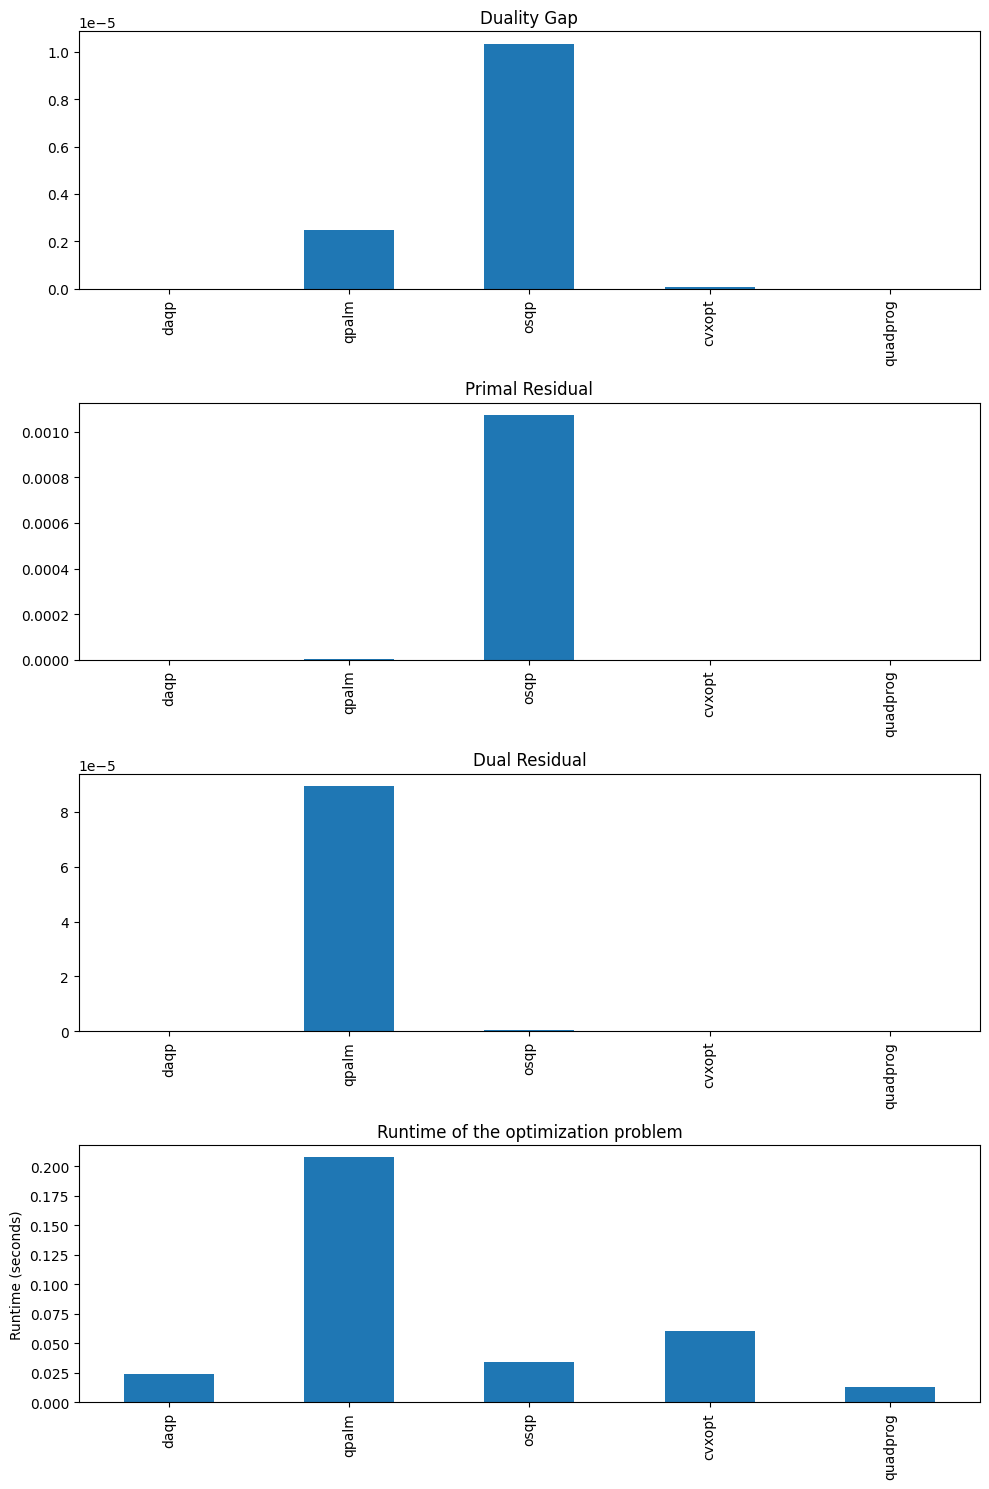

In [19]:
# Extract names of solvers which found a solution
sol_found = results_df.columns[results_df.loc['solution_found'] == True]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 15))

# Plot runtimes
results_df.loc['runtime', sol_found].plot(kind='bar', title='Runtime of the optimization problem', ylabel='Runtime (seconds)')

# Plot duality gap
results_df.loc['duality_gap', sol_found].plot(kind='bar', ax=axes[0], title='Duality Gap')

# Plot primal residual
results_df.loc['primal_residual', sol_found].plot(kind='bar', ax=axes[1], title='Primal Residual')

# Plot dual residual
results_df.loc['dual_residual', sol_found].plot(kind='bar', ax=axes[2], title='Dual Residual')

# Adjust layout
plt.tight_layout()

# Display the plots
plt.show()

## 2. Analytical Solution to Minimum-Variance Problem

(5 points)

- Create a `MinVariance` class that follows the structure of the `MeanVariance` class.
- Implement the `solve` method in `MinVariance` such that if `solver_name = 'analytical'`, the analytical solution is computed and stored within the object (if such a solution exists). If not, call the `solve` method from the parent class.
- Create a `Constraints` object by injecting the same ids as in part 1.b) and add a budget constraint.
- Instantiate a `MinVariance` object by setting `solver_name = 'analytical'` and passing instances of `Constraints` and `Covariance` as arguments.
- Create an `OptimizationData` object that contains an element `return_series`, which consists of the synthetic data generated in part 1.a).
- Solve the optimization problem using the created `MinVariance` object and compare the results to those obtained in part 1.c).


<Axes: title={'center': 'Analytical portfolio weights'}, ylabel='Weight'>

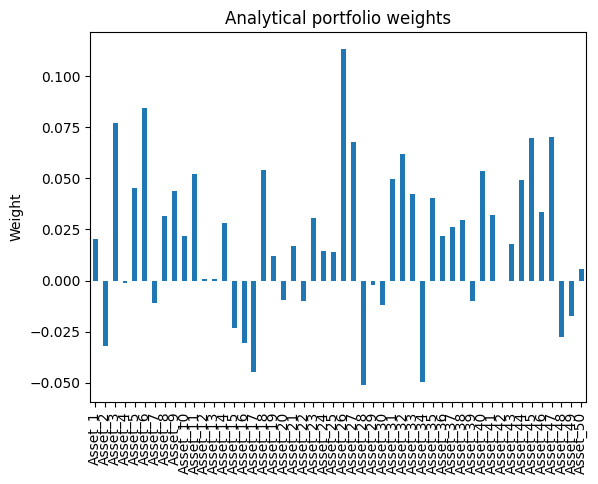

In [7]:
# Define class MinVariance
class MinVariance(Optimization):

    def __init__(self,
                 constraints: Constraints,
                 covariance: Optional[Covariance] = None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        mu = np.zeros(X.shape[1])
        self.objective = Objective(
            q = mu ,
            P = covmat * 2,
        )
        return None

    def solve(self) -> None:
        if self.params.get('solver_name') == 'analytical':
            GhAb = self.constraints.to_GhAb()
            if GhAb['G'] is not None:
                raise ValueError(
                    'Analytical solution does not exist whith inequality constraints.'
                )
            A = GhAb['A']
            b = GhAb['b']
            # If b is scalar, convert it to a 1D array
            if isinstance(b, (int, float)):
                b = np.array([b])
            elif b.ndim == 0:
                b = np.array([b])

            P = self.objective.coefficients['P'] / 2
            P_inv = np.linalg.inv(P)

            AP_invA = A @ P_inv @ A.T
            if AP_invA.shape[0] > 1:
                AP_invA_inv = np.linalg.inv(AP_invA)
            else:
                AP_invA_inv = 1 / AP_invA
            x = pd.Series(P_inv @ A.T @ AP_invA_inv @ b,
                          index=self.constraints.ids)      
            self.results.update({
                'weights': x.to_dict(),
                'status': True,
            })
            return None
        else:
            return super().solve()
    

# Create a constraints object with just a budget constraint
constraints = Constraints(ids=returns.columns.tolist())
constraints.add_budget(rhs=1, sense='=')

# Instantiate the MinVariance class
mv = MinVariance(
    constraints = constraints,
    covariance = Covariance(method='pearson'),
    risk_aversion = risk_aversion,
    solver_name = 'analytical'
)

# Prepare the optimization data and prepare the optimization problem
optimization_data = OptimizationData(return_series = returns)
mv.set_objective(optimization_data=optimization_data)

# Solve the optimization problem and compare the weights to solutions obtained in 1.c).
mv.solve()
weights_analytical = pd.Series(mv.results['weights'])

# weights_df = pd.concat({
#     **weights_dict,
#     'analytical': weights_analytical
# }, axis=1)
# weights_df.plot(kind='bar', title='Portfolio weights', ylabel='Weight')
weights_analytical.plot(kind='bar', title='Analytical portfolio weights', ylabel='Weight')